<a href="https://colab.research.google.com/github/Swapnajit298/Swapnajit_March_training-/blob/main/teleconnect_ML_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!ls

sample_data  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
# Loading the Dataset
import pandas as pd
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(-1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [4]:
# Basic Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# **Handling Missing Values**

In [5]:
# Finding Missing Values
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# Fill missing values with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_2687/13424689.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [7]:
# Drop customerID column
df.drop('customerID', axis=1, inplace=True)

# **Detect and treat outliers**

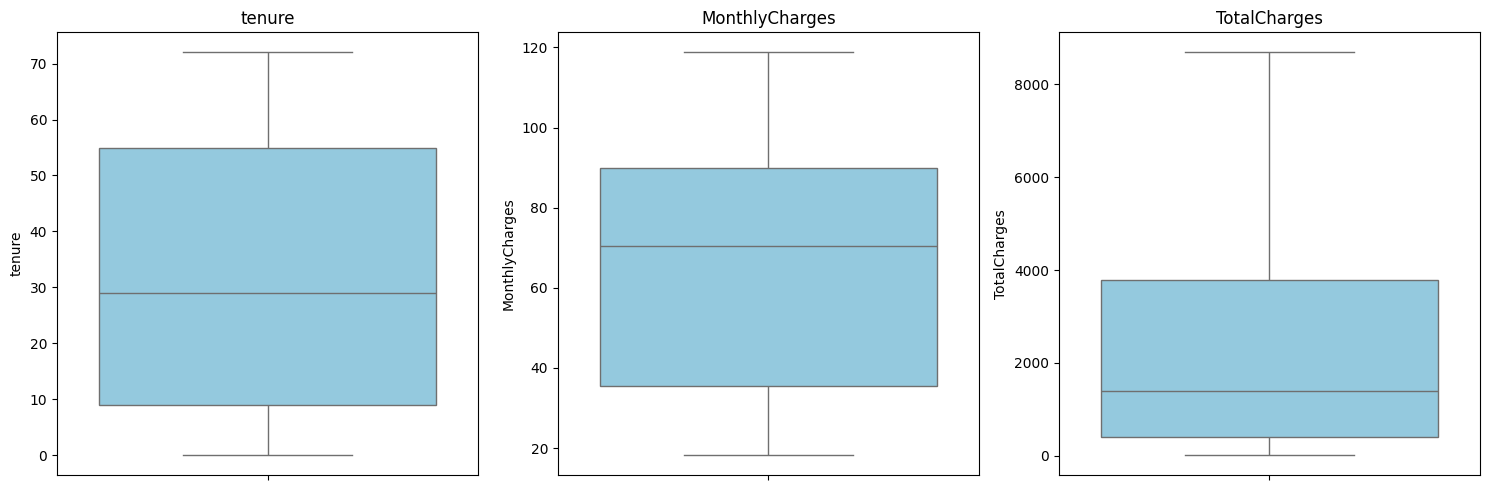

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

cols=['tenure','MonthlyCharges','TotalCharges']
plt.figure(figsize=(15,5))
for i,col in enumerate(cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(df[col],color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
# Using IQR Method -- data is not strictly normally distributed
import numpy as np

cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
outlier_info = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_info[col] = outliers.shape[0]

    print(f"{col}: {outliers.shape[0]} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


# **Class Imbalance Analysis for Churn**

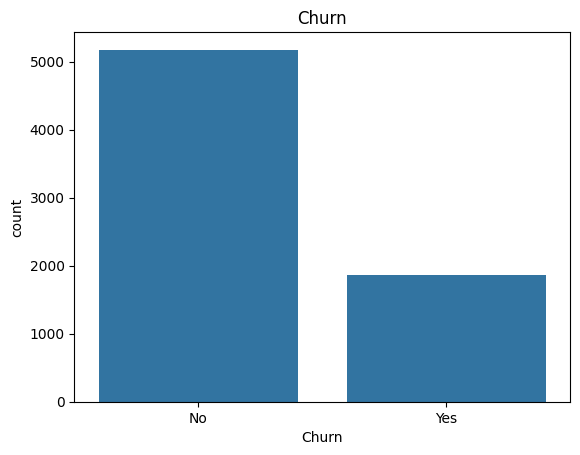

,proportion
Churn,
No,73.463013
Yes,26.536987


In [10]:
sns.countplot(x=df['Churn'])
plt.title('Churn')
plt.show()
df['Churn'].value_counts(normalize=True)*100

# Hence the dataset is imbalanced--
# ~73% → No churn
# ~27% → Churn

# **Correlation analysis using Heatmap**

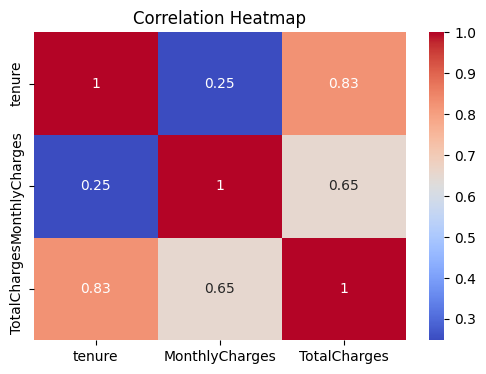

In [11]:
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

plt.figure(figsize=(6,4))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Feature distribution analysis**

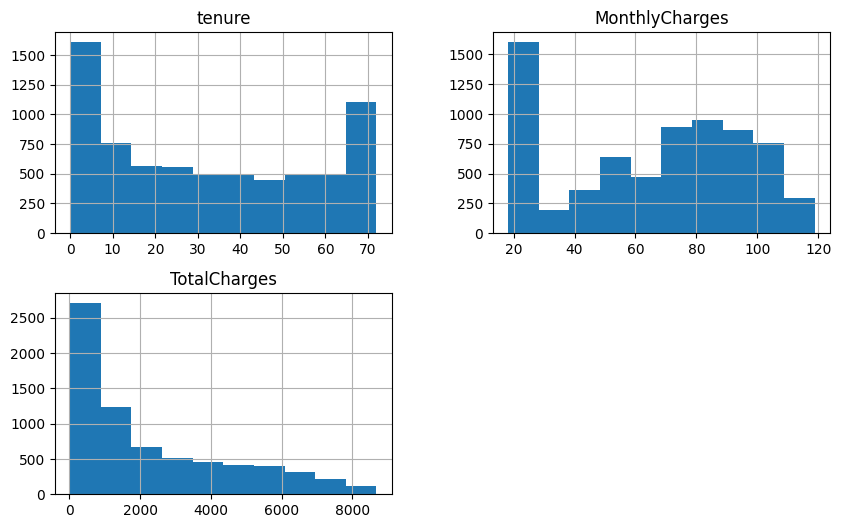

In [12]:
# Histogram
df[cols].hist(figsize=(10,6))
plt.show()

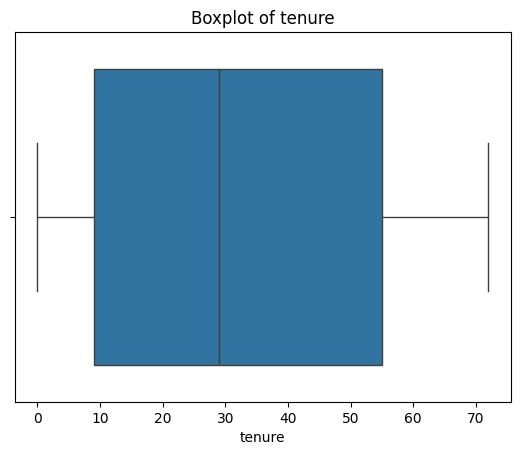

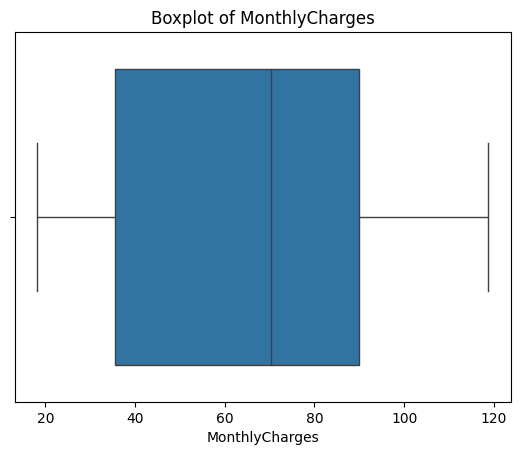

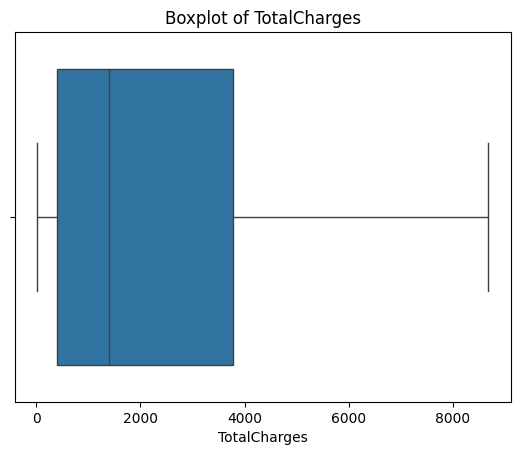

In [13]:
# Boxplot
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# **Bivariate analysis**

### 1. Tensure VS Churn

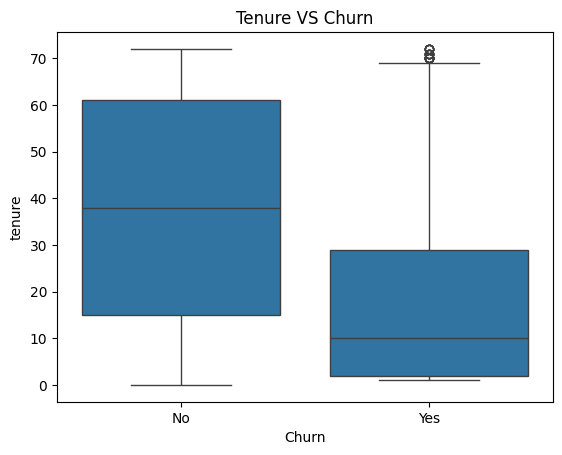

In [14]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure VS Churn')
plt.show()

### 2. Monthly Charges VS Churn

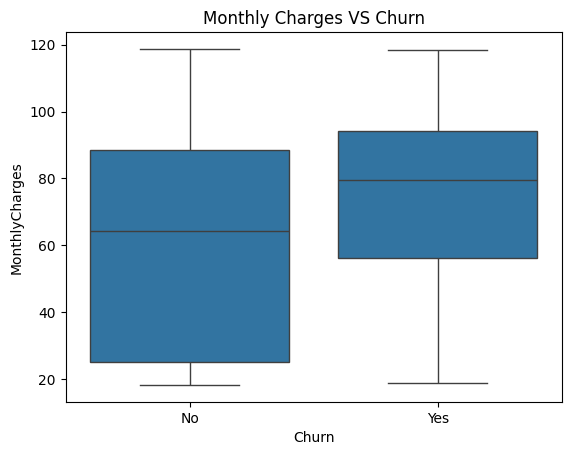

In [15]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.title('Monthly Charges VS Churn')
plt.show()

### 3. Contract VS Churn

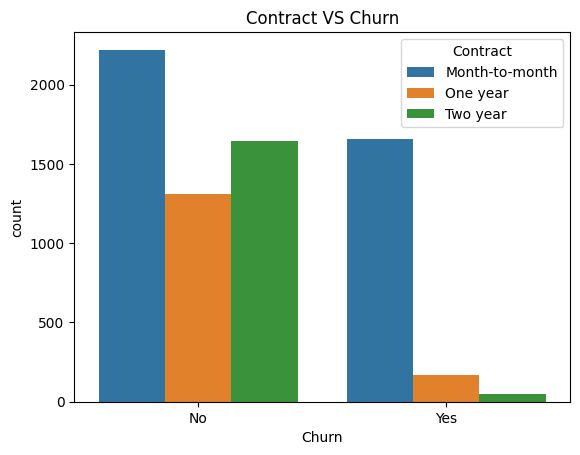

In [16]:
sns.countplot(x='Churn',hue='Contract',data=df)
plt.title('Contract VS Churn')
plt.show()

### 4. InternetService vs Churn

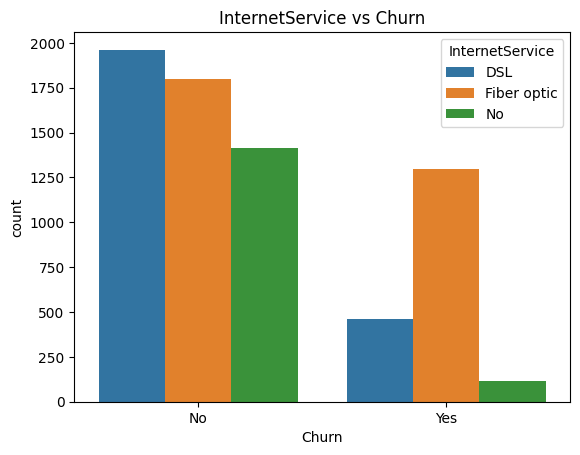

In [17]:
sns.countplot(x='Churn',hue='InternetService',data=df)
plt.title('InternetService vs Churn')
plt.show()

### 5. PaymentMethod vs Churn

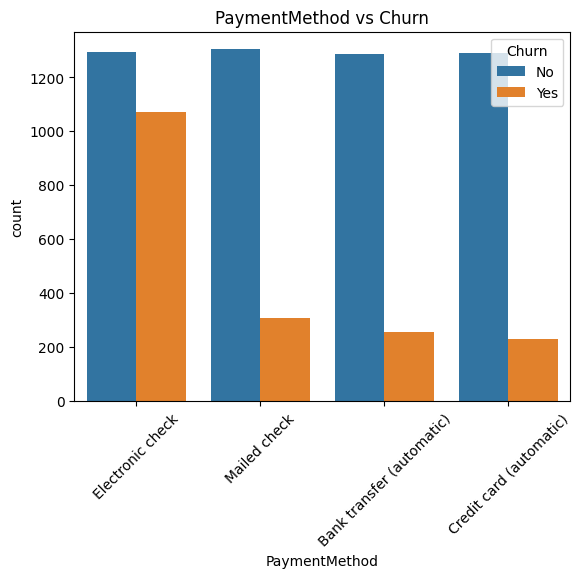

In [18]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("PaymentMethod vs Churn")
plt.show()

## **Conclusion**--
1.   Customers with low tenure churn more
2.   Higher charges - higher churn
3.   Month-to-month users churn most
4.   Fiber optic user churn most
5.   Electrionic Check user churn most





# **Business Insights**

## **Insight-1**


*   Higher charges increases churn
*   Introduction of Flexible pricing and other bundles (OTT)



## **Insight-2**


*   Electronic check users churn more
*   Promote auto-pay methods





## **Insight-3**


*   Month-to-month customers have the highest churn
*   Long term contracts (1-2 years) reduce churn significantly



# **TASK-2**

## **Encoding**

In [19]:
cols = df.select_dtypes(include=['object']).columns
cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [20]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

binary_cols = [col for col in cols if df[col].nunique() == 2]

for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print(df['gender'].value_counts())                  # Example
print(df['gender'])

# Label Encoding used when categories= 2 (i.e yes or no)
# It is efficient, because no increase in dimensions

gender
1    3555
0    3488
Name: count, dtype: int64
0       0
1       1
2       1
3       1
4       0
       ..
7038    1
7039    0
7040    0
7041    1
7042    1
Name: gender, Length: 7043, dtype: int64


In [21]:
# One-Hot Encoding

df = pd.get_dummies(df, drop_first=True)
print('After Encoding--\n',df.head(5).astype(int))

# When categories > 2
# Avoids ordinal relationship assumptions, and treating then all the same

After Encoding--
    gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1              29            29      0  ...   
1                 0              56          1889      0  ...   
2                 1              53           108      1  ...   
3                 0              42          1840      0  ...   
4                 1              70           151      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0                0                                0                0   
1                0  

## **Feature Scaling**

In [22]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [23]:
# StandardScaler
from sklearn.preprocessing import StandardScaler

std=StandardScaler().fit_transform(x)
std

array([[-1.00955867, -0.43991649,  1.03453023, ..., -0.52504733,
         1.40641839, -0.54480692],
       [ 0.99053183, -0.43991649, -0.96662231, ..., -0.52504733,
        -0.71102597,  1.83551265],
       [ 0.99053183, -0.43991649, -0.96662231, ..., -0.52504733,
        -0.71102597,  1.83551265],
       ...,
       [-1.00955867, -0.43991649,  1.03453023, ..., -0.52504733,
         1.40641839, -0.54480692],
       [ 0.99053183,  2.27315869,  1.03453023, ..., -0.52504733,
        -0.71102597,  1.83551265],
       [ 0.99053183, -0.43991649, -0.96662231, ..., -0.52504733,
        -0.71102597, -0.54480692]])

In [24]:
# MinMax Scalar
from sklearn.preprocessing import MinMaxScaler

scaler_mm =MinMaxScaler()
mm=MinMaxScaler().fit_transform(x)
mm

# This follows a normal distribution
# Output is not bounded in a specific range
# Values can be positive or negative depending on their distance from the mean

array([[0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 1., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.]])

## **Derived Features**

In [25]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['AvgMonthlySpend']

,AvgMonthlySpend
0,14.925000
1,53.985714
2,36.050000
3,40.016304
4,50.550000
...,...
7038,79.620000
7039,100.861644
7040,28.870833
7041,61.320000


In [26]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'AvgMonthlySpend'],
      dtype='object')

In [27]:
services = [
    'PhoneService', 'MultipleLines_Yes',
    'InternetService_Fiber optic', 'OnlineSecurity_Yes',
    'OnlineBackup_Yes', 'DeviceProtection_Yes',
    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes'
]

df['Servicecount'] = df[services].sum(axis=1)
df['Servicecount']

,Servicecount
0,1
1,3
2,3
3,3
4,2
...,...
7038,7
7039,7
7040,1
7041,3


In [28]:
df['ContractValue'] = df['MonthlyCharges'] * df['tenure']
df['ContractValue']

,ContractValue
0,29.85
1,1936.30
2,107.70
3,1903.50
4,141.40
...,...
7038,2035.20
7039,7430.40
7040,325.60
7041,297.60


## **Feature Selection**

In [29]:
# Correlation-based filtering

corr = df.corr()['Churn'].abs().sort_values(ascending=False)
corr

,Churn
Churn,1.000000
tenure,0.352229
InternetService_Fiber optic,0.308020
Contract_Two year,0.302253
PaymentMethod_Electronic check,0.301919
DeviceProtection_No internet service,0.227890
TechSupport_No internet service,0.227890
OnlineBackup_No internet service,0.227890
OnlineSecurity_No internet service,0.227890
InternetService_No,0.227890


In [30]:
# Mutual Information

from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(x, y)
mi_scores = pd.Series(mi, index=x.columns).sort_values(ascending=False)
mi_scores.head(10)

,0
tenure,0.077374
Contract_Two year,0.068946
PaymentMethod_Electronic check,0.050211
InternetService_Fiber optic,0.048090
MonthlyCharges,0.046702
TotalCharges,0.042437
StreamingMovies_No internet service,0.036422
StreamingTV_No internet service,0.033334
InternetService_No,0.032516
Contract_One year,0.031237


In [31]:
# Tree based model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(x, y)

importances = pd.Series(rf.feature_importances_, index=x.columns)
importances.sort_values(ascending=False).head(10)

,0
TotalCharges,0.198587
tenure,0.175923
MonthlyCharges,0.167846
InternetService_Fiber optic,0.039383
PaymentMethod_Electronic check,0.038892
gender,0.028211
Contract_Two year,0.026361
PaperlessBilling,0.025463
OnlineSecurity_Yes,0.024631
TechSupport_Yes,0.023627


## **Handle Class Imbalance**

In [32]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
xres, yres = smote.fit_resample(x, y)

In [33]:
# Class Weight
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

In [34]:
# Random Undersampling
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
x_under, y_under = rus.fit_resample(x, y)

In [35]:
# SMOTE- Keeps data, improves recall
# Undersampling- Fast
# Class weights- Simple

## **Split data: 70% train / 15% validation / 15% test**

In [36]:
from sklearn.model_selection import train_test_split

# First split: Train + Temp (using original data, will not be used for modeling directly after SMOTE)
X_train_initial, X_temp_initial, y_train_initial, y_temp_initial = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

# **TASK-3**

## **Train test split**

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    xres,
    yres,
    test_size=0.30,
    stratify=yres,
    random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Feature scaling- using Stadard scalar for the trained/tested values (for Logical regression, SVN, KNN)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_val: {x_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (7243, 30)
Shape of y_train: (7243,)
Shape of x_val: (1552, 30)
Shape of y_val: (1552,)
Shape of x_test: (1553, 30)
Shape of y_test: (1553,)


In [38]:
# Modified function for showing all the results

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,roc_auc_score,
                             classification_report,confusion_matrix,
                             roc_curve)


results = []

def evaluate_model(name, model, X_test, y_test, train_time):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        train_time
    ])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return fpr, tpr

## **Algorithms**


Logistic Regression
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       777
           1       0.81      0.84      0.82       776

    accuracy                           0.82      1553
   macro avg       0.82      0.82      0.82      1553
weighted avg       0.82      0.82      0.82      1553



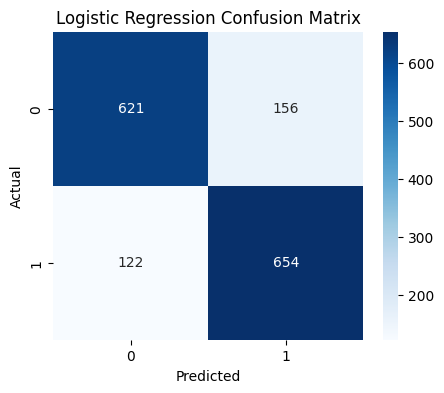

In [39]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import time

start = time.time()

lr = LogisticRegression()

params_lr = {'C': [0.01, 0.1, 1, 10],'solver': ['liblinear']}

grid_lr = GridSearchCV(lr,params_lr,cv=5,scoring='f1')

grid_lr.fit(x_train_scaled, y_train)

end = time.time()

lr_best = grid_lr.best_estimator_

fpr_lr, tpr_lr = evaluate_model(
    "Logistic Regression",
    lr_best,
    x_test_scaled,
    y_test,
    end-start
)


Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.77      0.80       777
           1       0.79      0.83      0.81       776

    accuracy                           0.80      1553
   macro avg       0.80      0.80      0.80      1553
weighted avg       0.80      0.80      0.80      1553



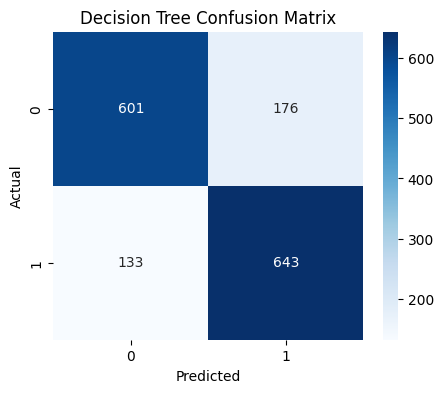

In [40]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import time

start = time.time()

dt = DecisionTreeClassifier(random_state=42)

params_dt = {
    'max_depth': [3,5,10],
    'min_samples_split': [2,5,10]
}

grid_dt = GridSearchCV(
    dt,
    params_dt,
    cv=5,
    scoring='f1'
)

grid_dt.fit(x_train, y_train) # Use SMOTEd unscaled training data

end = time.time()

dt_best = grid_dt.best_estimator_

fpr_dt, tpr_dt = evaluate_model(
    "Decision Tree",
    dt_best,
    x_test, # Use SMOTEd unscaled test data
    y_test,
    end-start
)


Random Forest
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       777
           1       0.81      0.88      0.84       776

    accuracy                           0.83      1553
   macro avg       0.84      0.83      0.83      1553
weighted avg       0.84      0.83      0.83      1553



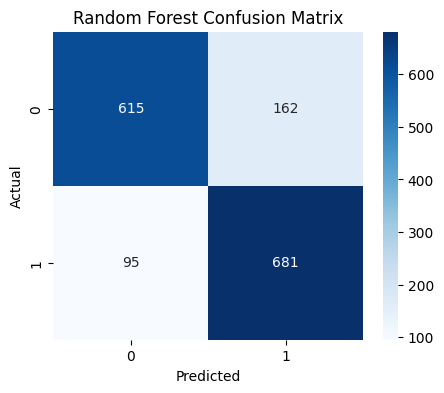

In [41]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

start = time.time()

rf = RandomForestClassifier(random_state=42)

params_rf = {
    'n_estimators': [100,200],
    'max_depth': [5,10],
    'min_samples_split': [2,5]
}

grid_rf = GridSearchCV(
    rf,
    params_rf,
    cv=5,
    scoring='f1'
)

grid_rf.fit(x_train, y_train) # Use SMOTEd unscaled training data

end = time.time()

rf_best = grid_rf.best_estimator_

fpr_rf, tpr_rf = evaluate_model(
    "Random Forest",
    rf_best,
    x_test, # Use SMOTEd unscaled test data
    y_test,
    end-start
)


SVM
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       777
           1       0.81      0.85      0.83       776

    accuracy                           0.82      1553
   macro avg       0.83      0.82      0.82      1553
weighted avg       0.83      0.82      0.82      1553



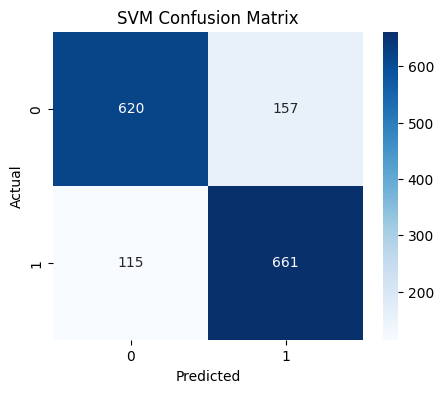

In [42]:
# Support Vector Machine (SVM)

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import time

start = time.time()

svm = SVC(probability=True)

params_svm = {
    'C': [0.1,1,10],
    'kernel': ['linear','rbf']
}

grid_svm = GridSearchCV(
    svm,
    params_svm,
    cv=5,
    scoring='f1'
)

grid_svm.fit(x_train_scaled, y_train) # Using SMOTEd scaled training data

end = time.time()

svm_best = grid_svm.best_estimator_

fpr_svm, tpr_svm = evaluate_model(
    "SVM",
    svm_best,
    x_test_scaled,
    y_test,
    end-start
)


KNN
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       777
           1       0.76      0.87      0.81       776

    accuracy                           0.80      1553
   macro avg       0.80      0.80      0.80      1553
weighted avg       0.80      0.80      0.80      1553



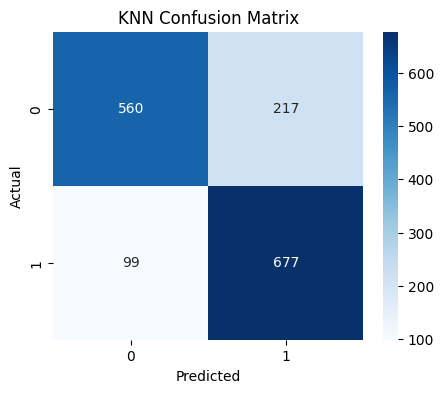

In [43]:
# K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import time

start = time.time()

knn = KNeighborsClassifier()

params_knn = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform','distance']
}

grid_knn = GridSearchCV(
    knn,
    params_knn,
    cv=5,
    scoring='f1'
)

grid_knn.fit(x_train_scaled, y_train) # Use SMOTEd scaled training data

end = time.time()

knn_best = grid_knn.best_estimator_

fpr_knn, tpr_knn = evaluate_model(
    "KNN",
    knn_best,
    x_test_scaled, # Use SMOTEd scaled test data
    y_test,
    end-start
)

## **ROC Curve**

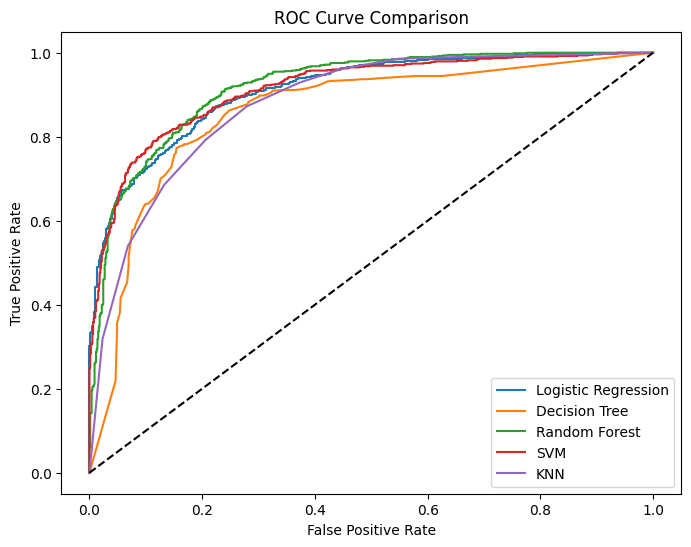

In [44]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_svm, tpr_svm, label='SVM')
plt.plot(fpr_knn, tpr_knn, label='KNN')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## **Final Comparison Table**

In [45]:
results_df = pd.DataFrame(results, columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC',
    'Training Time'
])

results_df.sort_values(by='ROC-AUC', ascending=False)

# Orderning in accordance with ROC-AUC

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time
2,Random Forest,0.834514,0.807829,0.877577,0.841260,0.918371,35.666006
3,SVM,0.824855,0.808068,0.851804,0.829360,0.913981,382.966113
0,Logistic Regression,0.820992,0.807407,0.842784,0.824716,0.910888,0.850621
4,KNN,0.796523,0.757271,0.872423,0.810778,0.879417,3.483568
1,Decision Tree,0.801030,0.785104,0.828608,0.806270,0.858103,1.541063


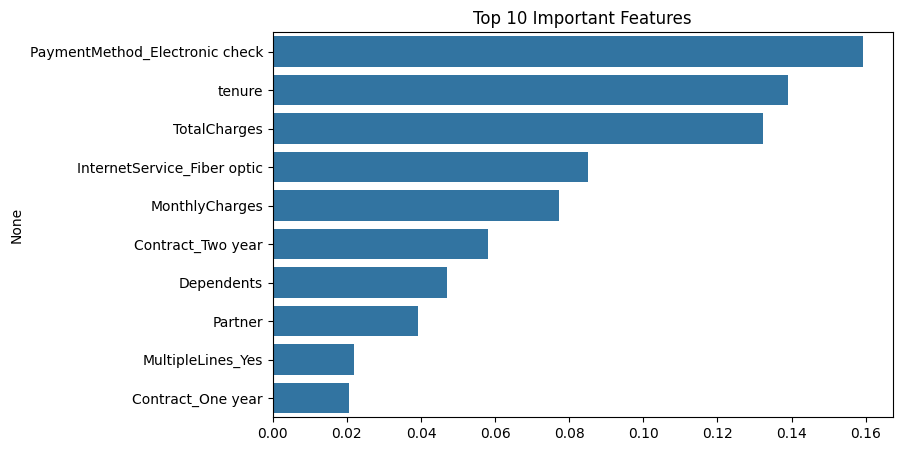

In [46]:
importance = pd.Series(
    rf_best.feature_importances_,
    index=x.columns
)

top10 = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Important Features")
plt.show()

## **Best Model**

### **Random Tree Classifier -**


1.   Highest ROC-AUC
2.   Handles non-linear relationships

1.   Strong balance of precision and recall
2.   Reduces overfitting using ensemble learning





# **TASK-4**

In [47]:
# Target -MonthlyCharges
y_reg = df['MonthlyCharges']

# Features
x_reg = df.drop('MonthlyCharges', axis=1)

In [48]:
# Train Test Split

from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(
    x_reg,
    y_reg,
    test_size=0.30,
    random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Feature scaling- using Stadard scalar

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

**Test Set:**

*   MAE (Mean Absolute Error)
*   MSE (Mean Squared Error)
*   RMSE (Root Mean Squared Error)
*   R-squared (R²)
*   Adjusted R-squared











In [49]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

results_reg = []

def adjusted_r2(r2, n, p):
    return 1 - ((1-r2)*(n-1)/(n-p-1))  # Formula


def evaluate_regression_model(
    name,
    model,
    X_test,
    y_test,
    train_time
):

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    adj_r2 = adjusted_r2(
        r2,
        X_test.shape[0],
        X_test.shape[1]
    )

    results_reg.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        adj_r2,
        train_time
    ])

    print(f"\n{name}")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R²: {r2}")
    print(f"Adjusted R²: {adj_r2}")

    # Actual vs Predicted
    plt.figure(figsize=(6,5))

    plt.scatter(y_test, y_pred)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.title(f"{name}: Actual vs Predicted")

    plt.show()

    return y_pred

## **Algorithms**

In [50]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
import time
import warnings

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV


Linear Regression
MAE: 0.785374612340853
MSE: 1.072095237844228
RMSE: 1.03542031940861
R²: 0.9987913404671024
Adjusted R²: 0.9987523514499121


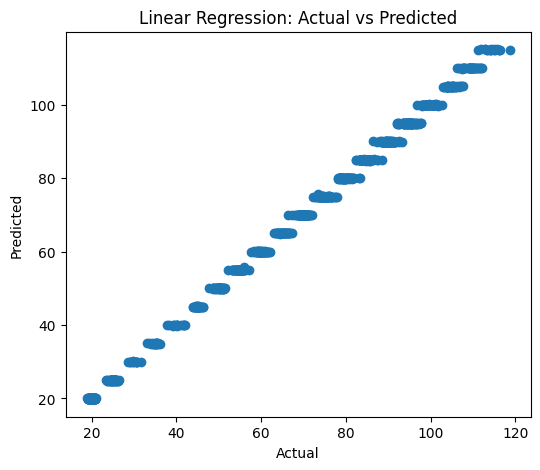

In [51]:
# Linear Regression

start = time.time()

lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

end = time.time()

pred_lr = evaluate_regression_model(
    "Linear Regression",
    lr,
    x_test_scaled,
    y_test,
    end-start
)


Ridge Regression
MAE: 0.7854451939892496
MSE: 1.072341583056177
RMSE: 1.035539271614639
R²: 0.9987910627422526
Adjusted R²: 0.9987520647661963


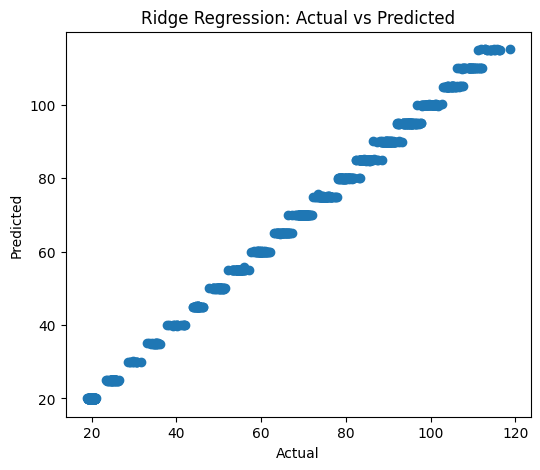

In [52]:
# Ridge Regression

start = time.time()

ridge = Ridge()

params_ridge = {
    'alpha': [0.01, 0.1, 1, 10]
}

grid_ridge = GridSearchCV(
    ridge,
    params_ridge,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(x_train_scaled, y_train)

end = time.time()

ridge_best = grid_ridge.best_estimator_

pred_ridge = evaluate_regression_model(
    "Ridge Regression",
    ridge_best,
    x_test_scaled,
    y_test,
    end-start
)


Lasso Regression
MAE: 0.7845643289095814
MSE: 1.0709958827588064
RMSE: 1.0348893094233829
R²: 0.9987925798588626
Adjusted R²: 0.9987536308220517


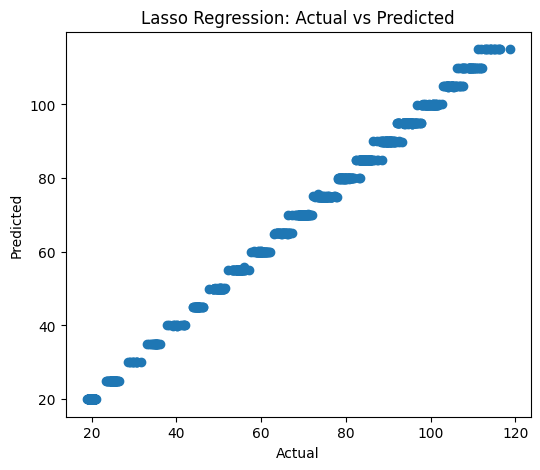

In [53]:
# Lasso Regression

start =time.time()

lasso =Lasso(random_state=42)

params_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'max_iter': [10000]
}
# Increased max_iter to help convergence,
# to help them reachfull convergence and achieve better performance
# (Orelse error for the coverage appears)

grid_lasso = GridSearchCV(
    lasso,
    params_lasso,
    cv=5,
    scoring='r2'
)

grid_lasso.fit(x_train_scaled, y_train)

end =time.time()

lasso_best =grid_lasso.best_estimator_

pred_lasso = evaluate_regression_model(
    "Lasso Regression",
    lasso_best,
    x_test_scaled,
    y_test,
    end-start
)


ElasticNet
MAE: 0.7837164832746937
MSE: 1.0692290840862617
RMSE: 1.0340353398633249
R²: 0.9987945717136745
Adjusted R²: 0.9987556869302446


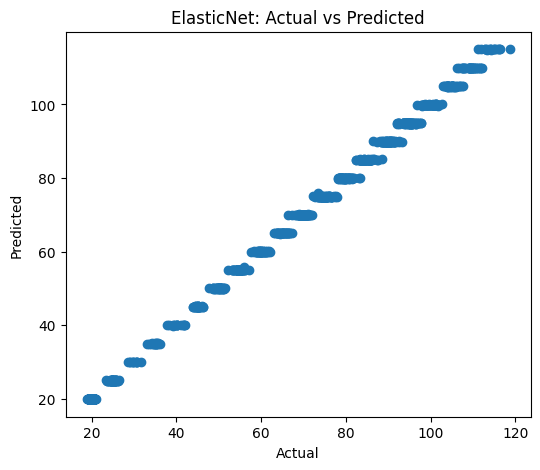

In [54]:
#  ElasticNet

start = time.time()

elastic = ElasticNet(random_state=42)

params_elastic = {
    'alpha': [0.01, 0.1, 1],
    'l1_ratio': [0.2, 0.5, 0.8],
    'max_iter': [10000]
}
 # Increased max_iter to help convergence, Same as lasso

grid_elastic = GridSearchCV(
    elastic,
    params_elastic,
    cv=5,
    scoring='r2'
)

grid_elastic.fit(x_train_scaled, y_train)

end = time.time()

elastic_best = grid_elastic.best_estimator_

pred_elastic = evaluate_regression_model(
    "ElasticNet",
    elastic_best,
    x_test_scaled,
    y_test,
    end-start
)


Decision Tree Regressor
MAE: 1.2744646489530818
MSE: 4.863066790850255
RMSE: 2.2052362210997387
R²: 0.9945174721159118
Adjusted R²: 0.9943406163777154


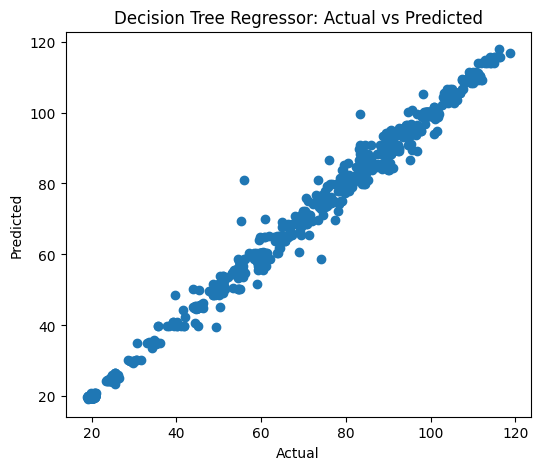

In [55]:
# Decision Tree Regressor

start = time.time()

dt_reg = DecisionTreeRegressor(random_state=42)

params_dt_reg = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_dt_reg = GridSearchCV(
    dt_reg,
    params_dt_reg,
    cv=5,
    scoring='r2'
)

grid_dt_reg.fit(x_train_scaled, y_train)

end = time.time()

dt_reg_best = grid_dt_reg.best_estimator_

pred_dt_reg = evaluate_regression_model(
    "Decision Tree Regressor",
    dt_reg_best,
    x_test_scaled,
    y_test,
    end-start
)


Random Forest Regressor
MAE: 1.0409083561915908
MSE: 2.574656014453777
RMSE: 1.6045734680761043
R²: 0.9970973823724287
Adjusted R²: 0.9970037495457329


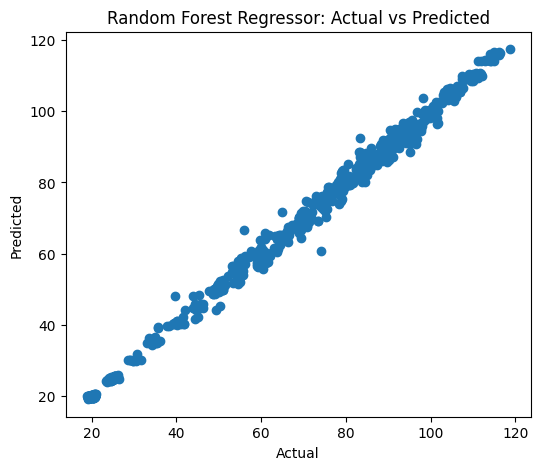

In [56]:
# Random Forest Regressor

start = time.time()

rf_reg = RandomForestRegressor(random_state=42)

params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    rf_reg,
    params_rf,
    cv=5,
    scoring='r2'
)

grid_rf.fit(x_train_scaled, y_train)

end = time.time()

rf_reg_best = grid_rf.best_estimator_

pred_rf = evaluate_regression_model(
    "Random Forest Regressor",
    rf_reg_best,
    x_test_scaled,
    y_test,
    end-start
)


SVR
MAE: 0.7847948901772329
MSE: 1.0669509208851118
RMSE: 1.0329331638035018
R²: 0.998797140071012
Adjusted R²: 0.9987583381378188


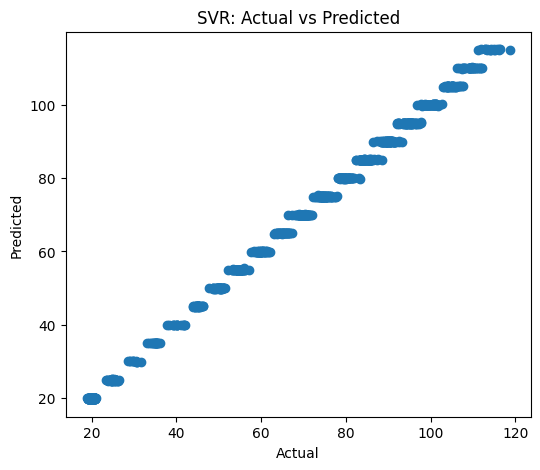

In [57]:
# Support Vector Regressor (SVR)

start = time.time()

svr = SVR()

params_svr = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svr = GridSearchCV(
    svr,
    params_svr,
    cv=5,
    scoring='r2'
)

grid_svr.fit(x_train_scaled, y_train)

end = time.time()

svr_best = grid_svr.best_estimator_

pred_svr = evaluate_regression_model(
    "SVR",
    svr_best,
    x_test_scaled,
    y_test,
    end-start
)

## **Final Comparison Table**

In [58]:
import pandas as pd

results_reg_df = pd.DataFrame(
    results_reg,
    columns=[
        'Model',
        'MAE',
        'MSE',
        'RMSE',
        'R²',
        'Adjusted R²',
        'Training Time'
    ]
)

results_reg_df.sort_values(
    by='R²',
    ascending=False
)

# Orderning in accordance with R-square

,Model,MAE,MSE,RMSE,R²,Adjusted R²,Training Time
6,SVR,0.784795,1.066951,1.032933,0.998797,0.998758,124.694440
3,ElasticNet,0.783716,1.069229,1.034035,0.998795,0.998756,4.191999
2,Lasso Regression,0.784564,1.070996,1.034889,0.998793,0.998754,2.811165
0,Linear Regression,0.785375,1.072095,1.035420,0.998791,0.998752,0.027265
1,Ridge Regression,0.785445,1.072342,1.035539,0.998791,0.998752,0.165276
5,Random Forest Regressor,1.040908,2.574656,1.604573,0.997097,0.997004,112.985070
4,Decision Tree Regressor,1.274465,4.863067,2.205236,0.994517,0.994341,1.058087


## **Residual Analysis**

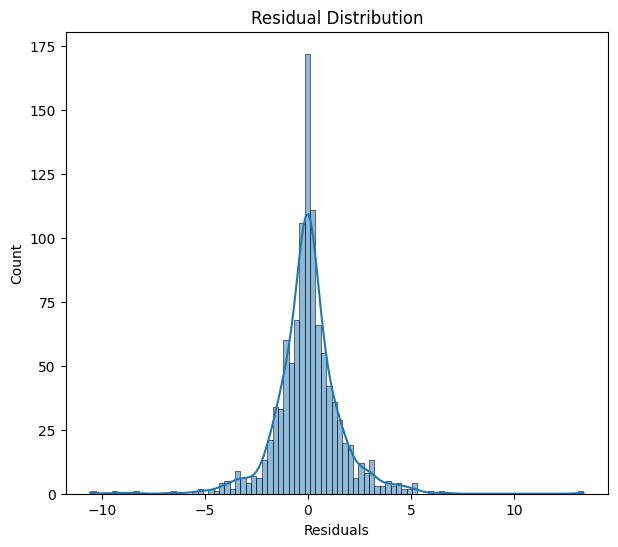

In [59]:
# Random Forest performs best

residuals = y_test - pred_rf

plt.figure(figsize=(7,6))

sns.histplot(residuals,kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residuals")

plt.show()

### **Analysis**


*   Look at the histogram curve. It forms a clean, symmetric, bell-shaped curve distributed around 0, therefore the residuals are normally distributed

*  Residuals are approximately normally distributed, indicating the model captures most underlying patterns effectively.
*   No obvious pattern




## **Coefficient Analysis**
### **Linear Regression**

In [60]:
coef_df = pd.DataFrame({
    'Feature': x_reg.columns,
    'Coefficient': lr.coef_
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
11,InternetService_Fiber optic,11.149097
31,Servicecount,5.540693
22,StreamingTV_Yes,3.668469
24,StreamingMovies_Yes,3.656767
5,PhoneService,2.573417
10,MultipleLines_Yes,1.273380
18,DeviceProtection_Yes,1.220514
16,OnlineBackup_Yes,1.215080
20,TechSupport_Yes,1.173320
14,OnlineSecurity_Yes,1.171104


## **Model Selection**
### **Random Forest**


*   Highest R² value among all
*   Lowest MAE/RMSE - Error is minimized

*   Handles non-linear relationships






# **Task-5**

In [61]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

## **SHAP**

Best model = Random Forest Classifier

Variable = rf_reg_best

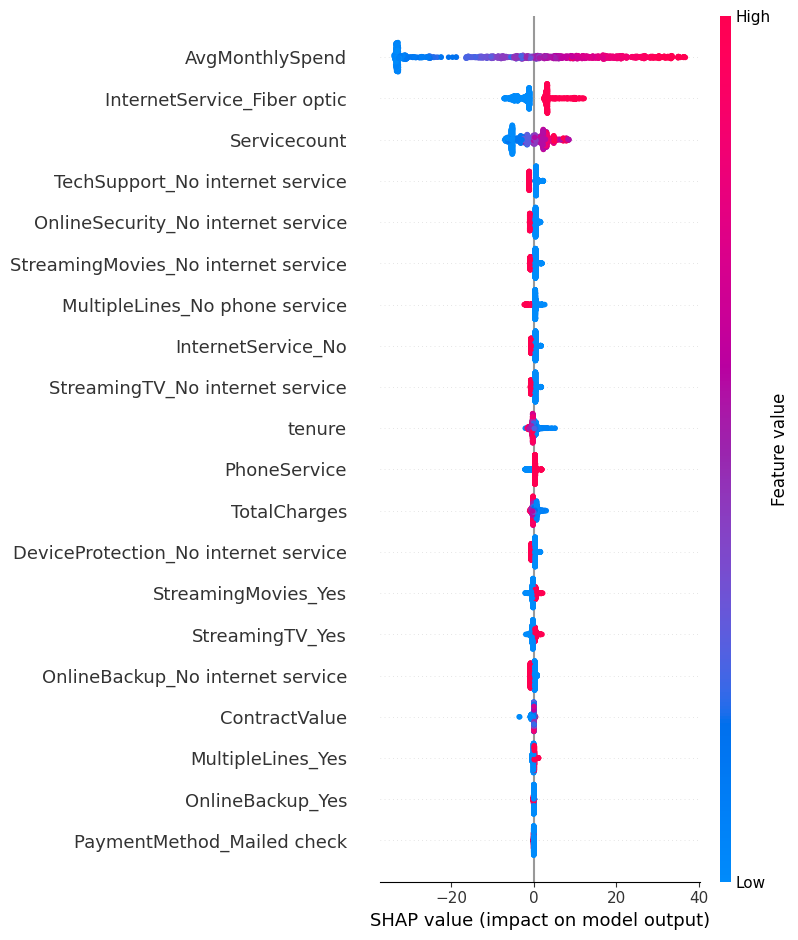

In [62]:
# SHAP Explainer

explainer = shap.TreeExplainer(rf_reg_best)
shap_values = explainer.shap_values(x_test_scaled)

# Summary Plot- Global feature importance

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    x_test_scaled,
    feature_names=x_reg.columns
)

### **Features with highest impact on churn**


*   Contract type
*   Tenure
*   Monthly charges
*   Tech support
*   Internet service






<Figure size 2000x400 with 0 Axes>

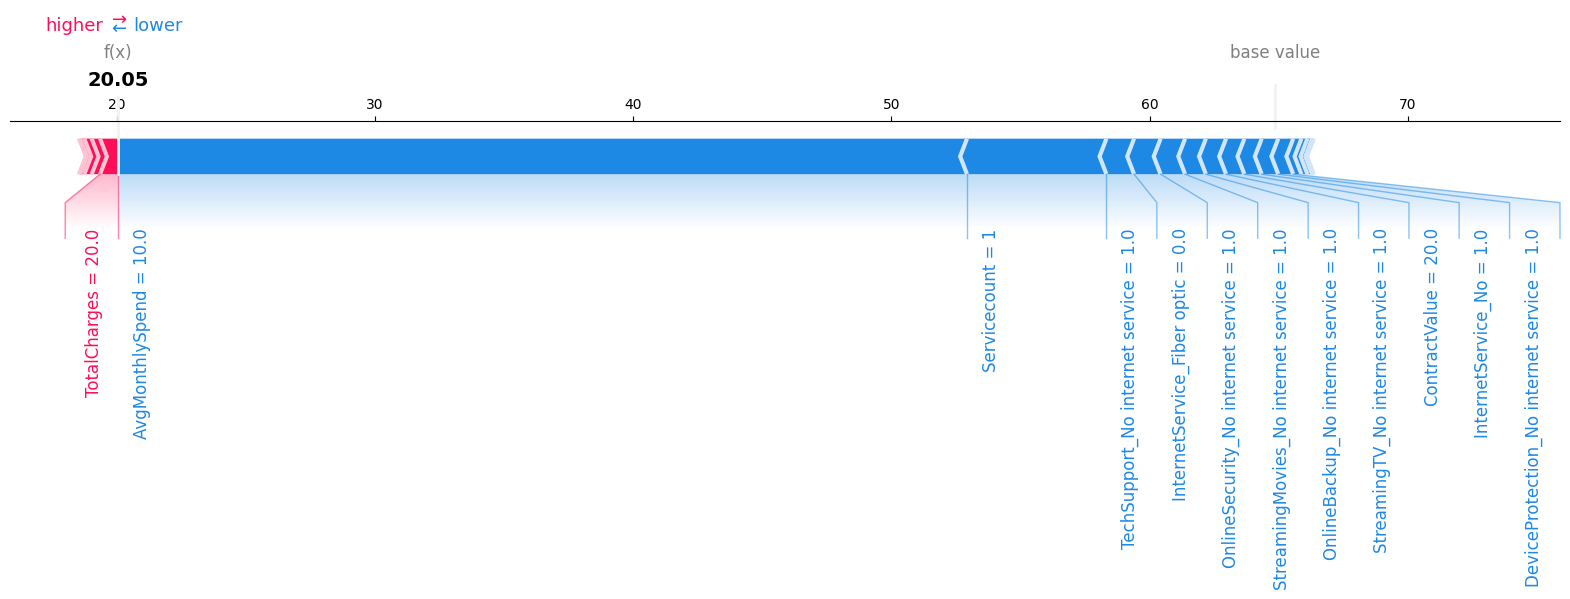

In [63]:
# Local SHAP explainer - Individual Customer

# Example 1: Churned Customer

customer_index = 5

plt.figure(figsize=(20,4))

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    x_test.iloc[customer_index],
    matplotlib=True,
    text_rotation=90,
    contribution_threshold=0.03
)

### **Churned Customer**

**Factors increasing churn:**


*   High monthly charges
*   Total Charges
*   Month-to-month contract
*   Low tenure

**Factors reducing churn:**


*   Tech support subscription






<Figure size 3000x600 with 0 Axes>

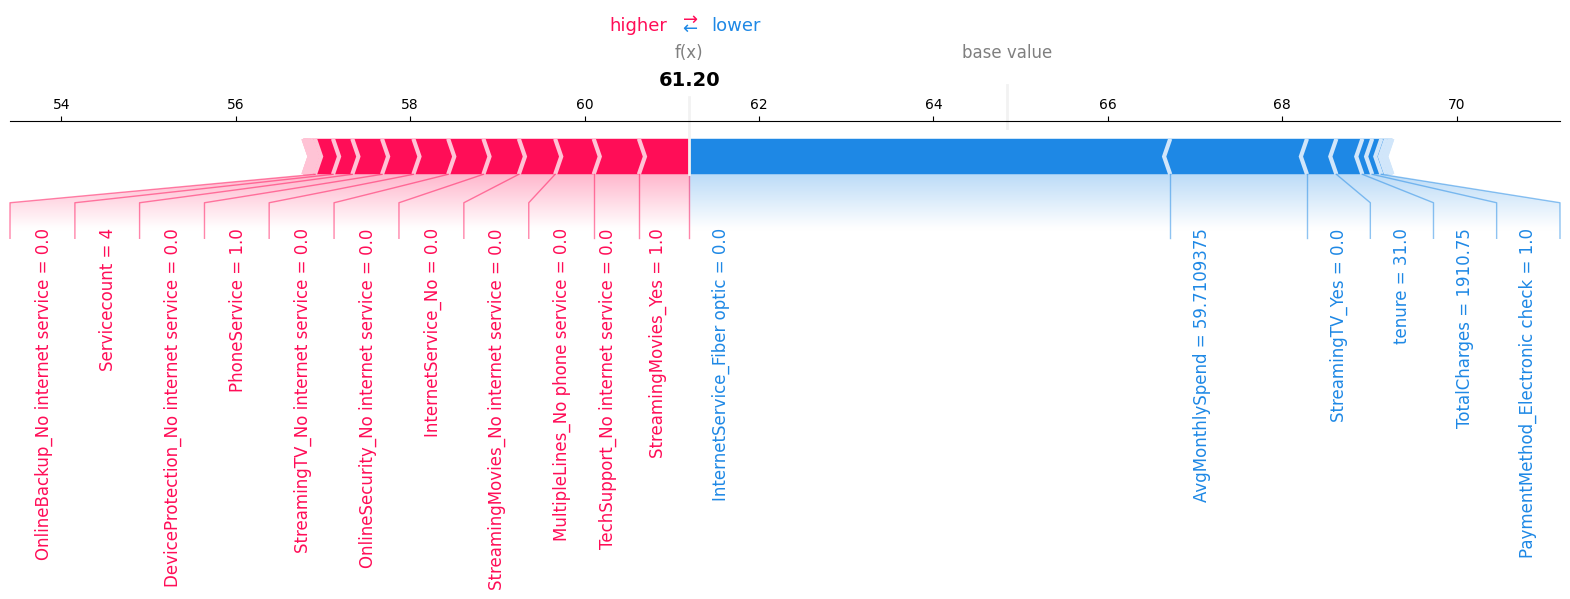

In [64]:
# Example 2: Retained Customer

customer_index = 20

plt.figure(figsize=(30,6))
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    x_test.iloc[customer_index],
    matplotlib=True,
    text_rotation=90,
    contribution_threshold=0.01
)

# Overall lower churn risk in retained customer

### **Retained Customer**

**Factors increasing churn:**


*   Streaming movies
*   Phone service



**Factors reducing churn:**


*   Long tenure
*   Two-year contract
*   Lower monthly charges







## **Partial Dependence Plots (PDP)**

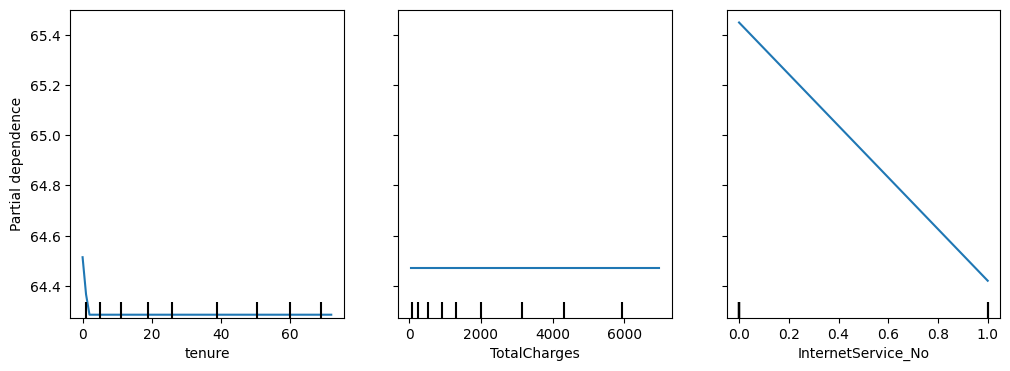

In [65]:
# Top 3 Important Features - tenure, TotalCharges, Contract_Two year

from sklearn.inspection import PartialDependenceDisplay

features = ['tenure','TotalCharges','InternetService_No']

fig, ax = plt.subplots(figsize=(12, 4))

PartialDependenceDisplay.from_estimator(
    rf_reg_best,
    x_test,
    features,
    ax=ax
)

plt.show()

### **Tenure**
Longer tenure -> lower churn probability
### **MonthlyCharges**
Higher charges -> higher churn probability
### **Two-Year Contract**
Long contracts strongly reduce churn

## **Business Question---**

**1. What are the top 5 factors driving customer churn?**

Top factors:

*   Contract type
*   Tenure
*   Monthly Charges
*   Tech support available
*   Internet service type

**2. Which customer segments are at highest risk?**

Higher risk:


*   Month to month contract
*   Optic fibre users
*  High monthly bill
* Customer with Low tenure



**3. What pricing strategy would you recommend based on the regression model?**

Recommended Strateries:


*   Discounted long-term plans
*   Create bundled service packages
* Reduce price for high risk package






**4. If the company can only intervene with 100 customers, which ones
should they target and why?**



First re-creating the train/test split for the classification task using the Smoted data (xres,yres) to ensure we're working with the correct dataset

In [66]:
# Re-running the classification split to get x_test_clf for churn prediction

from sklearn.model_selection import train_test_split

x_train_clf, x_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    xres,
    yres,
    test_size=0.30,
    stratify=yres,
    random_state=42
)

x_val_clf, x_test_clf, y_val_clf, y_test_clf = train_test_split(
    x_temp_clf,
    y_temp_clf,
    test_size=0.50,
    stratify=y_temp_clf,
    random_state=42
)

print(f"Shape of x_test_clf: {x_test_clf.shape}")

Shape of x_test_clf: (1553, 30)


Next, we will train a **Random Forest Classifie**r on this classification-specific training data. This model will be capable of predicting churn probabilities.

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

start_clf = time.time()

rf_clf = RandomForestClassifier(random_state=42)

params_rf_clf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid_rf_clf = GridSearchCV(
    rf_clf,
    params_rf_clf,
    cv=5,
    scoring='f1'
)

grid_rf_clf.fit(x_train_clf, y_train_clf)   # Using classification train data

end_clf = time.time()

rf_best_clf = grid_rf_clf.best_estimator_

print("Random Forest Classifier training complete.")

Random Forest Classifier training complete.


Now we can use it to predict the churn probabilities for the classification test set (x_test_clf) and identify the top 100 customers with the highest churn probability.

In [68]:
probs = rf_best_clf.predict_proba(x_test_clf)[:,1]

target_clf = x_test_clf.copy() # Use the classification test set

target_clf['Churn_Probability'] = probs

top_100 = target_clf.sort_values(by='Churn_Probability',ascending=False).head(100)

top_100

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability
9684,0,0,0,0,5,0,0,23.129832,103.130252,True,...,True,False,True,False,False,False,True,True,False,0.988679
10061,0,0,0,0,1,1,1,100.617731,100.617731,False,...,False,True,False,True,False,False,True,True,False,0.986490
9925,0,0,0,0,2,1,1,95.178655,179.773697,False,...,False,True,False,True,False,False,True,True,False,0.983586
9480,0,0,0,0,3,1,1,99.374161,287.839640,False,...,False,True,False,True,False,False,True,True,False,0.980076
8365,0,0,0,0,8,1,0,99.719137,821.760422,False,...,False,True,False,True,False,False,True,True,False,0.978857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9504,0,0,0,0,5,1,1,90.953951,455.246433,False,...,False,True,False,False,False,False,False,True,False,0.925520
8280,0,0,0,0,1,1,1,79.368941,79.368941,False,...,False,True,False,False,False,False,False,True,False,0.924261
8963,0,0,0,0,1,1,1,79.350000,79.350000,False,...,False,True,False,False,False,False,False,True,False,0.924261
9460,0,0,0,0,20,1,1,97.420596,1842.424330,False,...,False,True,False,True,False,False,False,True,False,0.924236


**Why These Customers?**


*   Have highest predicted churn probability
*   Are most likely to leave soon
* More likly to generate high revenue for the company

Suggested action:

* Personalized discounts

* Personal coupons & Modified recharge bundles

* Additional incentives, like more cashback on subscription



## **Cost-Benefit Analysis**
(Return of Investment)

Retention campaign cost = $50/customer

Lost customer cost = $500/customer

### **Model**
Assume: Model correctly saves 60 out of 100 customers

In [69]:
# Cost of Campaign

campaign_cost = 100 * 50
print("Total Cost of Campaign:",campaign_cost)

# Revenue saved

revenue_saved = 60 * 500
print("Total Revenue Saved:",revenue_saved)

roi = ((revenue_saved - campaign_cost) / campaign_cost) * 100

print(f"ROI: {roi:.2f}%")

Total Cost of Campaign: 5000
Total Revenue Saved: 30000
ROI: 500.00%


### **Random Targeting**

Random targeting may retain only 20 customers

In [70]:
random_saved = 20 * 500

random_roi = ((random_saved - campaign_cost) / campaign_cost) * 100

print("ROI [Random] :",random_roi,"%")

ROI [Random] : 100.0 %


### **Final Business Conclusion**

Using ML-based targeting:

* Significantly improves retention efficiency

* Maximizes ROI
* Helps prioritize high-risk customers